__If you are new to PheTK, please check out the APOE PheWAS - Logistic Regression notebook first.__

This notebook demonstrates how to run a Cox regression PheWAS with the same APOE cohort. Most of the steps are similar to the first notebook, with some additional features used for Cox regression.

## Initial setup

In [1]:
!pip install --upgrade \
--index-url https://test.pypi.org/simple/ \
--extra-index-url https://pypi.org/simple/ \
phetk==0.2.1rc132

Looking in indexes: https://test.pypi.org/simple/, https://pypi.org/simple/



[notice] A new release of pip is available: 25.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip show PheTK | grep Version

Version: 0.2.1rc132


__Please restart the notebook kernel before proceeding to the next step.__

In [1]:
from phetk.cohort import Cohort
from phetk.phecode import Phecode
from phetk.phewas import PheWAS
from phetk.plot import Plot

## Cox regression PheWAS

Additional parameters for Cox proportional hazards regression:
- `cox_start_date_col`: Column with study start dates (str, required)
- `cox_control_observed_time_col`: Column with censoring time for controls (str, required)
- `cox_phecode_observed_time_col`: Column with time to event for cases (str, required)
- `cox_stratification_col`: Column for stratification (str, optional)
- `cox_fallback_step_size`: Step size for convergence issues (float, optional, default: 0.1)

In this example, we will use date of birth as start date, age at last EHR event as control observed time, and age at first phecode event as phecode observed time. These can be extracted by Cohort (add date of birth and age at last EHR event as covariates to cohort file) and Phecode module (add age at first event to phecode counts file). Alternatively, users can provide such data on their own.

### Create cohort

In [2]:
%%time
# instantiate class Cohort for _All of Us_ database
cohort = Cohort(platform="aou", aou_db_version=8)

# generate cohort by genotype
cohort.by_genotype(
    chromosome_number=19,
    genomic_position=44908684,
    ref_allele="T",
    alt_allele="C",
    gt_dict={0: "0/0", 1:["0/1", "1/1"]},
    output_file_path="cox__rs429358_cohort.tsv"
)

Loading BokehJS ...

/opt/conda/lib/python3.10/site-packages/hail/context.py:350: UserWarning:

Using hl.init with a default_reference argument is deprecated. To set a default reference genome after initializing hail, call `hl.default_reference` with an argument to set the default reference genome.

/opt/conda/lib/python3.10/site-packages/hailtop/aiocloud/aiogoogle/user_config.py:43: UserWarning:

Reading spark-defaults.conf to determine GCS requester pays configuration. This is deprecated. Please use `hailctl config set gcs_requester_pays/project` and `hailctl config set gcs_requester_pays/buckets`.

Running on Apache Spark version 3.5.3
SparkUI available at http://all-of-us-5797-m.us-central1-c.c.terra-vpc-sc-7883f2cd.internal:42227
Welcome to
     __  __     <>__
    / /_/ /__  __/ /
   / __  / _ `/ / /
  /_/ /_/\_,_/_/_/   version 0.2.134-952ae203dbbe
LOGGING: writing to /home/jupyter/workspaces/phetkv8/hail-20250729-1653-0.2.134-952ae203dbbe.log



Locus chr19:44908684 found!


+----------------+------------+----------+---------+-----------+
| locus          | alleles    | filters  | a_index | was_split |
+----------------+------------+----------+---------+-----------+
| locus<GRCh38>  | array<str> | set<str> |   int32 |      bool |
+----------------+------------+----------+---------+-----------+
| chr19:44908684 | ["T","C"]  | {}       |       1 |     False |
+----------------+------------+----------+---------+-----------+

+--------------------------+---------------------------+
| variant_qc.gq_stats.mean | variant_qc.gq_stats.stdev |
+--------------------------+---------------------------+
|                  float64 |                   float64 |
+--------------------------+---------------------------+
|                 4.30e+01 |                  8.93e+00 |
+--------------------------+---------------------------+

+-------------------------+-------------------------+----------------------+
| variant_qc.gq_stats.min | variant_qc.gq_stats.max | variant_qc.call_rate |
+-------------------------+-------------------------+----------------------+
|                 float64 |                 float64 |              float64 |
+-------------------------+-------------------------+----------------------+
|                6.00e+00 |                9.90e+01 |             1.00e+00 |
+-------------------------+-------------------------+----------------------+

+---------------------+-------------------------+-----------------------+
| variant_qc.n_called | variant_qc.n_not_called | variant_qc.n_filtered |
+---------------------+-------------------------+-----------------------+
|               int64 |                   int64 |                 int64 |
+---------------------+-------------------------+-----------------------+
|              414715 |                       0 |                   115 |
+---------------------+-------------------------+-----------------------+

+------------------+----------------------+-------------------------+
| variant_qc.n_het | variant_qc.n_non_ref | variant_qc.het_freq_hwe |
+------------------+----------------------+-------------------------+
|            int64 |                int64 |                 float64 |
+------------------+----------------------+-------------------------+
|           103189 |               112726 |                2.51e-01 |
+------------------+----------------------+-------------------------+

+------------------------+-------------------------------+--------------+
| variant_qc.p_value_hwe | variant_qc.p_value_excess_het | info.AC      |
+------------------------+-------------------------------+--------------+
|                float64 |                       float64 | array<int32> |
+------------------------+-------------------------------+--------------+
|               1.05e-10 |                      1.00e+00 | [122263]     |
+------------------------+-------------------------------+--------------+

+----------------+---------+-----------------------+
| info.AF        | info.AN | info.homozygote_count |
+----------------+---------+-----------------------+
| array<float64> |   int32 | array<int32>          |
+----------------+---------+-----------------------+
| [1.47e-01]     |  829430 | [301989,9537]         |
+----------------+---------+-----------------------+

2025-07-29 16:54:02.892 Hail: WARN: entries(): Resulting entries table is sorted by '(row_key, col_key)'.
    To preserve row-major matrix table order, first unkey columns with 'key_cols_by()'



Variant chr19:44908684:T:C found!


+----------------+------------+----------+---------+-----------+
| locus          | alleles    | filters  | a_index | was_split |
+----------------+------------+----------+---------+-----------+
| locus<GRCh38>  | array<str> | set<str> |   int32 |      bool |
+----------------+------------+----------+---------+-----------+
| chr19:44908684 | ["T","C"]  | {}       |       1 |     False |
+----------------+------------+----------+---------+-----------+

+--------------------------+---------------------------+
| variant_qc.gq_stats.mean | variant_qc.gq_stats.stdev |
+--------------------------+---------------------------+
|                  float64 |                   float64 |
+--------------------------+---------------------------+
|                 4.30e+01 |                  8.93e+00 |
+--------------------------+---------------------------+

+-------------------------+-------------------------+----------------------+
| variant_qc.gq_stats.min | variant_qc.gq_stats.max | variant_qc.call_rate |
+-------------------------+-------------------------+----------------------+
|                 float64 |                 float64 |              float64 |
+-------------------------+-------------------------+----------------------+
|                6.00e+00 |                9.90e+01 |             1.00e+00 |
+-------------------------+-------------------------+----------------------+

+---------------------+-------------------------+-----------------------+
| variant_qc.n_called | variant_qc.n_not_called | variant_qc.n_filtered |
+---------------------+-------------------------+-----------------------+
|               int64 |                   int64 |                 int64 |
+---------------------+-------------------------+-----------------------+
|              414715 |                       0 |                   115 |
+---------------------+-------------------------+-----------------------+

+------------------+----------------------+-------------------------+
| variant_qc.n_het | variant_qc.n_non_ref | variant_qc.het_freq_hwe |
+------------------+----------------------+-------------------------+
|            int64 |                int64 |                 float64 |
+------------------+----------------------+-------------------------+
|           103189 |               112726 |                2.51e-01 |
+------------------+----------------------+-------------------------+

+------------------------+-------------------------------+--------------+
| variant_qc.p_value_hwe | variant_qc.p_value_excess_het | info.AC      |
+------------------------+-------------------------------+--------------+
|                float64 |                       float64 | array<int32> |
+------------------------+-------------------------------+--------------+
|               1.05e-10 |                      1.00e+00 | [122263]     |
+------------------------+-------------------------------+--------------+

+----------------+---------+-----------------------+
| info.AF        | info.AN | info.homozygote_count |
+----------------+---------+-----------------------+
| array<float64> |   int32 | array<int32>          |
+----------------+---------+-----------------------+
| [1.47e-01]     |  829430 | [301989,9537]         |
+----------------+---------+-----------------------+


Cohort size: 414703 participants
Genotype 0: 301989 participants
Genotype 1: 112714 participants

Cohort data saved as cox__rs429358_cohort.tsv!

CPU times: user 5.05 s, sys: 844 ms, total: 5.89 s
Wall time: 1min 55s


### Add covariates

In [3]:
%%time
cohort.add_covariates(
    cohort_file_path="cox__rs429358_cohort.tsv",
    date_of_birth=True,
    current_age=True,
    age_at_last_ehr_event=True,
    sex_at_birth=True,
    first_n_pcs=4,
    drop_nulls=True,
    output_file_path="cox__rs429358_cohort_with_covariates.tsv"
)

100%|██████████| 42/42 [02:26<00:00,  3.50s/it]



Cohort size: 280444 participants
Genotype 0: 204525 participants
Genotype 1: 75919 participants

Cohort data saved as "cox__rs429358_cohort_with_covariates.tsv"!

CPU times: user 16min, sys: 46.7 s, total: 16min 47s
Wall time: 2min 28s


### Generate phecode profiles

In [4]:
%%time
# instantiate class Phecode and provide some basic information
phecode = Phecode(platform="aou")

# generate phecode profiles/counts
phecode.count_phecode(
    phecode_version="X", 
    output_file_path="aou_phecode_counts.tsv"
)

Start querying ICD codes...
Done!

Mapping ICD codes to phecodeX...
Successfully generated phecodeX counts for cohort participants!

Saved to aou_phecode_counts.tsv

CPU times: user 4min 29s, sys: 40.7 s, total: 5min 10s
Wall time: 1min 5s


In [5]:
# add age at first event
phecode.add_age_at_first_event(
    phecode_count_file_path="aou_phecode_counts.tsv",
    output_file_path="cox__aou_phecode_counts.tsv"
)

Calculating age at first event...
Generating queries...


100%|██████████| 348/348 [00:00<00:00, 185583.95it/s]


Done!

Querying data...


100%|██████████| 348/348 [00:39<00:00,  8.83it/s]


Done!

Processing data...
Done!

Saved to cox__aou_phecode_counts.tsv. Age at first event column name is age_at_first_event.



### Cox Regression PheWAS

For most users, it is recommended to only set `method` but leave `batch_size` and `paralellization` unset - PheTK will choose the optimal values for each method.

The default `batch_size` for logistic regression and cox regression are 1 and 10 respectively. Advanced users could use these values as starting points for optimization.

In [6]:
%%time
# instantiate class PheWAS and provide information for the PheWAS run
phewas = PheWAS(
    phecode_version="X",
    phecode_count_file_path="cox__aou_phecode_counts.tsv",
    cohort_file_path="cox__rs429358_cohort_with_covariates.tsv",
    sex_at_birth_col="sex_at_birth",
    male_as_one=True,
    covariate_cols=["current_age", "sex_at_birth", "pc1", "pc2", "pc3", "pc4"],
    cox_start_date_col="date_of_birth",
    cox_control_observed_time_col="age_at_last_ehr_event",
    cox_phecode_observed_time_col="age_at_first_event",
    independent_variable_of_interest="genotype",
    min_cases=50,
    min_phecode_count=2,
    method="cox",
    output_file_path="cox__rs429358_phewas_results.tsv"
)

# run PheWAS
phewas.run()

~~~~~~~~~~~~~~~~~~~~~~~~~    Creating PheWAS Object    ~~~~~~~~~~~~~~~~~~~~~~~~~

Cohort size:  280444
genotype descriptions:  shape: (2, 2)
┌──────────┬────────┐
│ genotype ┆ count  │
│ ---      ┆ ---    │
│ i64      ┆ u32    │
╞══════════╪════════╡
│ 0        ┆ 204525 │
│ 1        ┆ 75919  │
└──────────┴────────┘

Number of unique phecodes in cohort:  3430
Total number of phecode events:  20812932
Number of phecode batches to process:  343

Analysis method:  Cox regression

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~    Running PheWAS    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Parallelization method: multiprocessing
Number of workers: 15

Initializing multiprocessing context...
Creating ProcessPoolExecutor...
Submitting jobs to workers...
Submitted 343 jobs. Running regressions...


Processed: 100%|██████████| 343/343 [56:06<00:00,  9.82s/it]  


Multiprocessing completed successfully.
Combining 343 result files...


Reading files: 100%|██████████| 343/343 [00:00<00:00, 435.67it/s]


Concatenating results...
Cleaning up temporary files...


Cleaning files: 100%|██████████| 343/343 [00:00<00:00, 32839.81it/s]



~~~~~~~~~~~~~~~~~~~~~~~~~~~~    PheWAS Completed    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Number of participants in cohort: 280444
Number of phecodes in cohort: 3430
Number of phecodes having less than 50 cases or controls: 913
Number of phecodes tested: 2517
Suggested Bonferroni correction (-log₁₀ scale): 4.701913211212344
Number of phecodes above Bonferroni correction: 15

PheWAS results saved to cox__rs429358_phewas_results.tsv 

CPU times: user 8min 32s, sys: 7min 49s, total: 16min 22s
Wall time: 56min 14s


### Result visualization

#### Manhattan plot

In [7]:
# instantiate class Plot with PheWAS results as input
p = Plot("cox__rs429358_phewas_results.tsv")

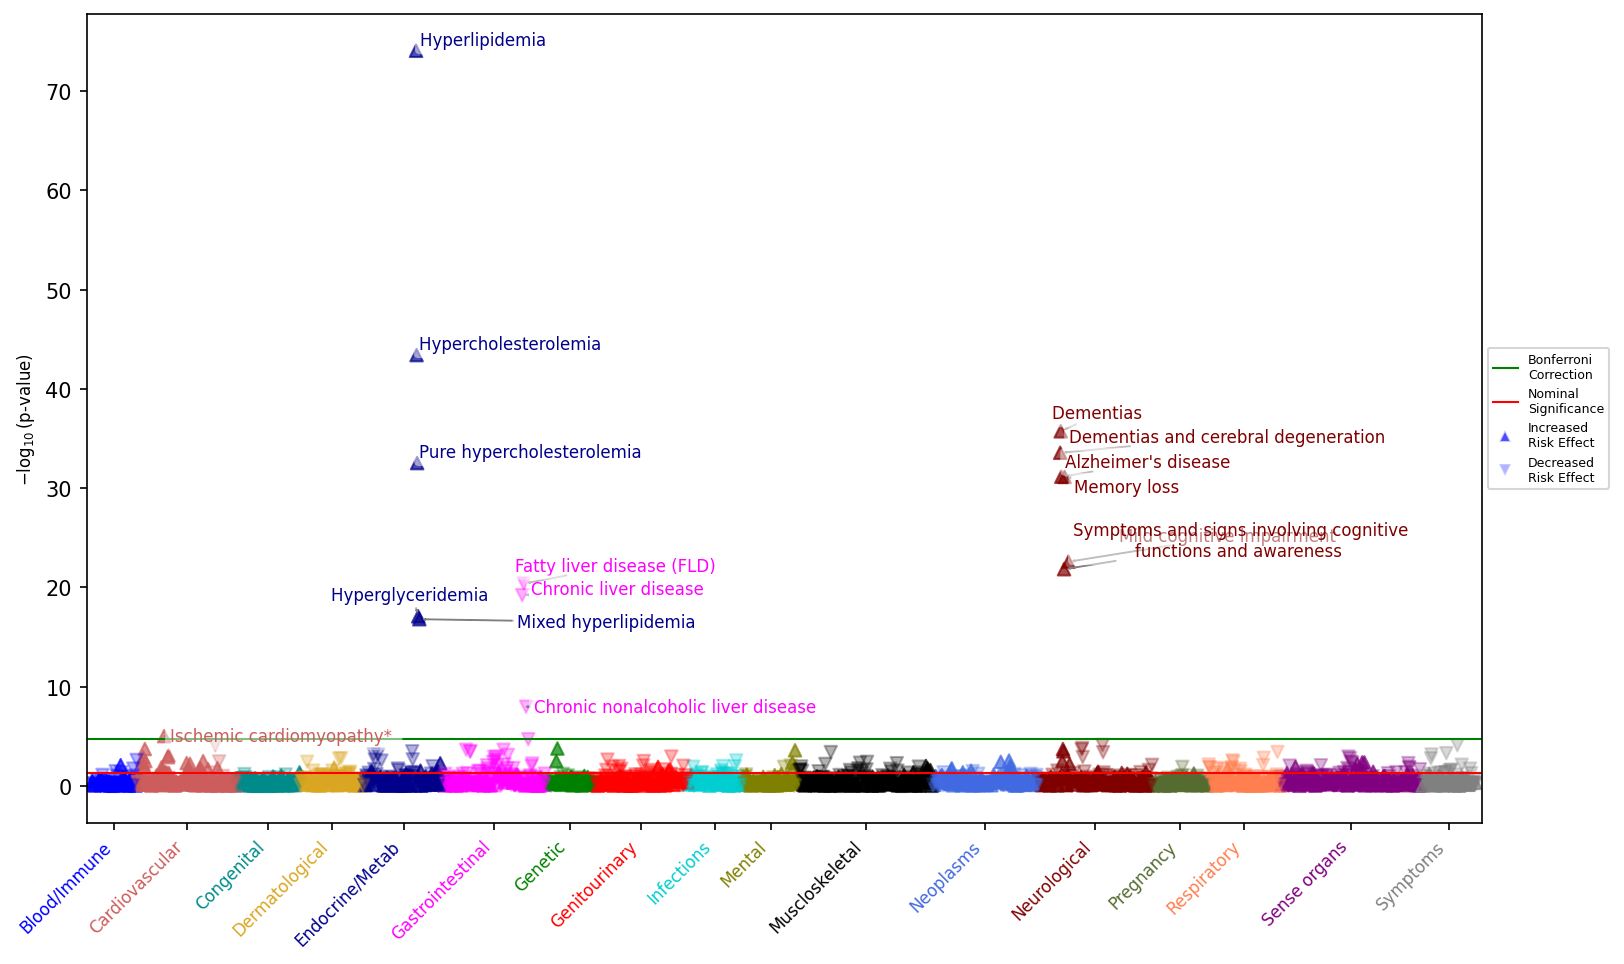

In [8]:
# generate Manhattan plot
p.manhattan(label_values="p_value", label_count=15, save_plot=False)

#### Forest plot

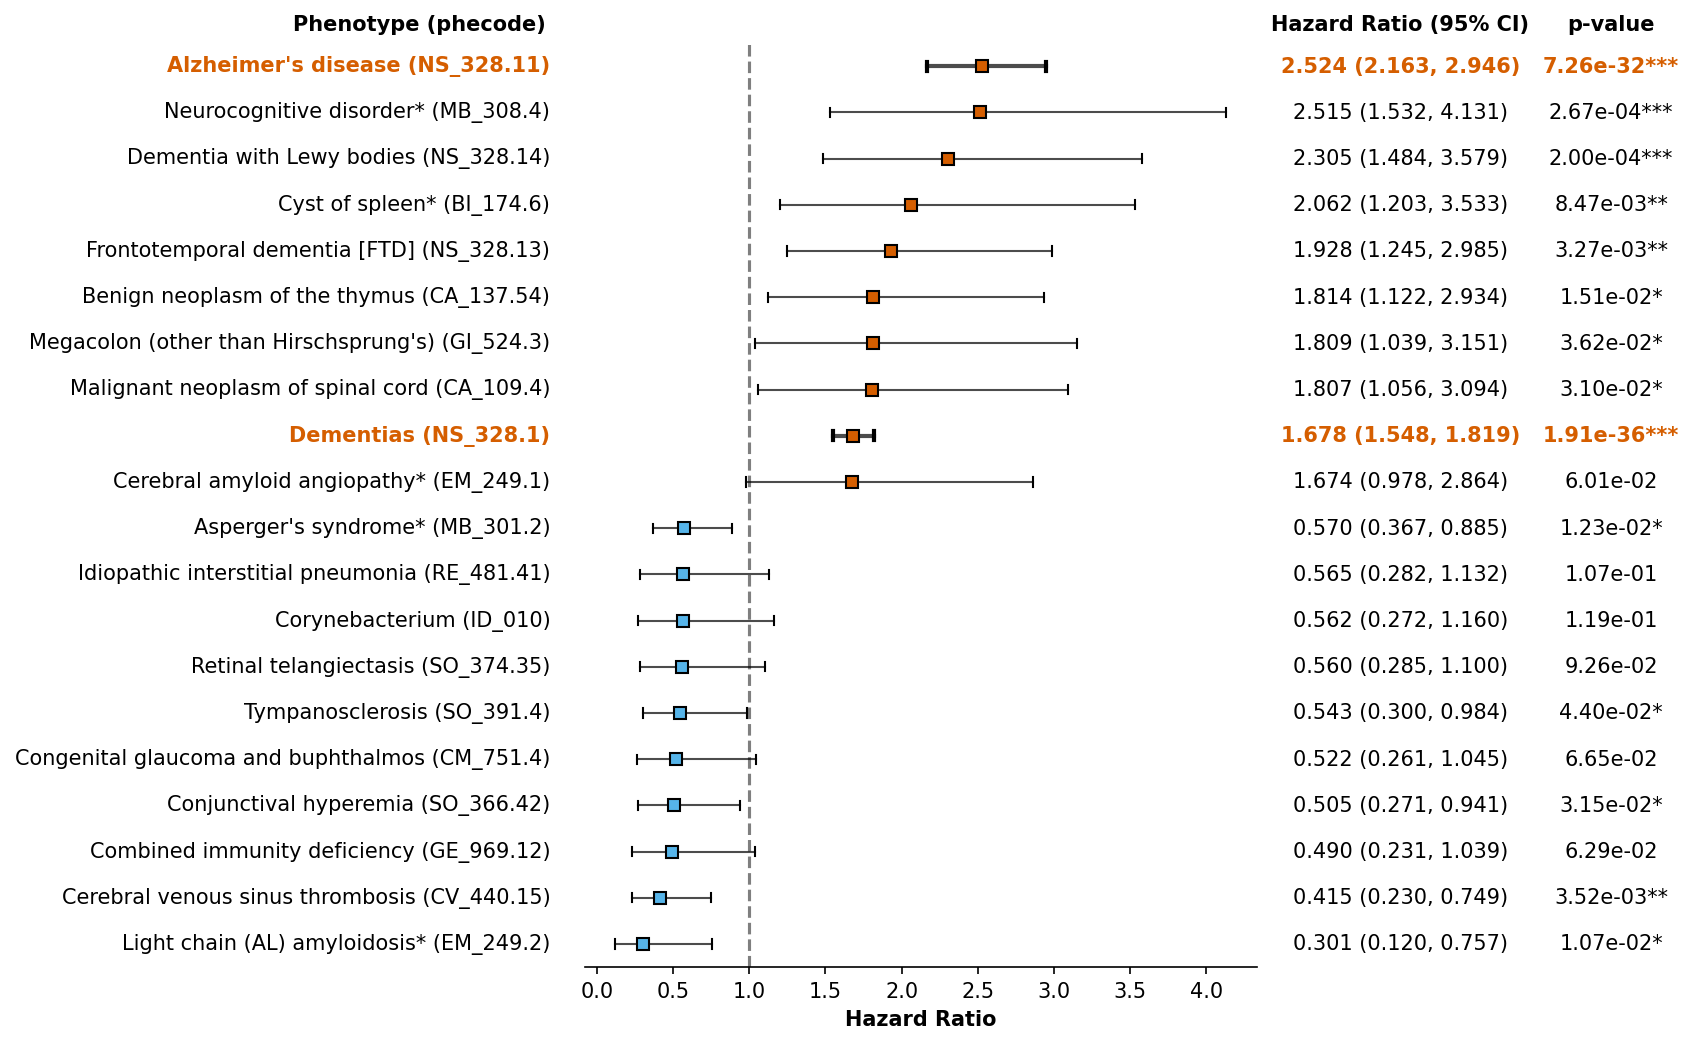

In [9]:
# generate forest plot; by default, it will show top 10 positive and negative phenotypes
p.forest(highlight_significance=True, show_p_value_asterisks=True, save_plot=False)